In [ ]:
import slangpy as spy
from pyglm import glm
import torch
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.model.cameras import PerspectiveCamera
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D

%load_ext autoreload
%autoreload 2

device = setup_device([])
renderer_modules = RendererModules(device)

[WARN] No supported shader model found, pretending to support sm_6_0.


In [50]:
OUTPUT_IMG_SIZE = (800, 800)
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)
# Setup the renderer
renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules
)
renderer.sqrt_spp = 1
renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

In [54]:
from cs231nfinal.data import DatasetID, DataSet
import numpy as np
from openvdb import FloatGrid

dataset = DataSet.Get(DatasetID.SMOKE_MIDRES)

data_array = np.zeros(dataset.resolution)
grid = dataset.get_grid("density", frame=70, type=FloatGrid)
# dataset = DataSet.Get(DatasetID.TORUS)
# data_array = np.zeros(dataset.resolution)
# grid = dataset.get_grid("density", frame=1, type=FloatGrid)

grid.copyToArray(data_array, ijk=grid.evalLeafBoundingBox()[0])
min, max = grid.evalMinMax()
data_array = 0.5 * ((data_array + min) / (max - min))

In [79]:
dense_volume = DenseVolume(
    name="volume",
    data=np.stack(
        3 * [np.zeros(dataset.resolution)] + [data_array], 
        axis=-1
    ).astype(np.float32),
    transform=Transform3D(position=glm.vec3(0,3,4)),
    properties={
        "pivot": (0.5, 0.5, 0.5),
        "voxel_size": dataset.voxel_size,
    },
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.020369364..1.0000575].


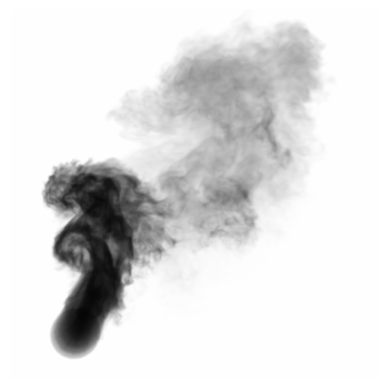

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00344861..1.0000591].


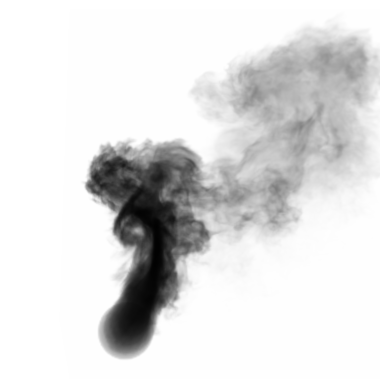

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0031873481..1.0000582].


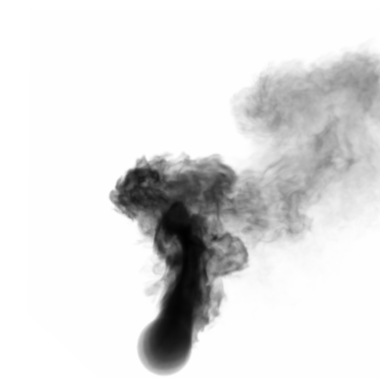

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021957722..1.0000572].


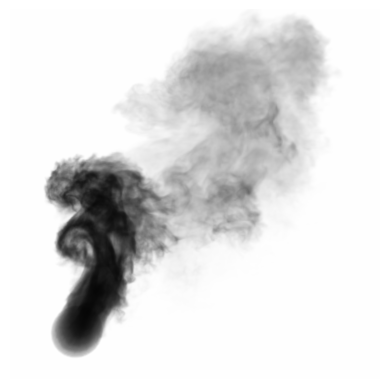

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.009349553..1.0000557].


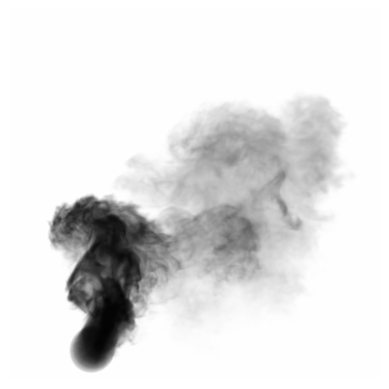

In [82]:
from cs231nfinal.camera import RandomCameraTransform

cam_tr = RandomCameraTransform(glm.vec3(25,0,0), sigma=1.0)
renderer.load_volume(volume=dense_volume)
fov = 40

for i in range(5):
    renderer.render(next(cam_tr), fov)

    img_res = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
    plt.imshow(img_res.detach().numpy())
    plt.axis("off")
    plt.show()

In [ ]:
num_epochs = 2
num_views = 10

volume_as_numpy = 
volume_tensor = torch.empty((*dataset.resolution, 4), dtype=torch.float32, requires_grad=True)
volume_tensor.nump

optim = torch.optim.Adam([])

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    for i in tqdm(range(num_views), desc="Views"):
        optim.zero_grad()